# Spatio-Temporal Query Generation Intuition

This notebook builds practical intuition for query generation parameters in OceanTACO.

It focuses on two APIs:
- `QueryGenerator.generate_training_queries(...)` for random training samples
- `QueryGenerator.generate_eval_queries(...)` for deterministic evaluation grids

The experiments are lightweight and do not require downloading OceanTACO tiles.

## 1. Imports and Setup

In [1]:
# Verify ocean_taco is installed.
# To install from GitHub: pip install "ocean_taco[hf] @ git+https://github.com/nilsleh/oceanTACO.git@main"
# To install from PyPI:   pip install ocean-taco[hf]
import ocean_taco
print(f"ocean_taco {ocean_taco.__version__} ready")

ocean_taco 0.1.0 ready


In [1]:
import os
from pathlib import Path

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ocean_taco.dataset import PatchSize, QueryGenerator

sns.set_context("paper", font_scale=1.1)
plt.rcParams["font.family"] = "serif"


def _configure_cartopy_dir(path: str):
    p = Path(path).expanduser()
    p.mkdir(parents=True, exist_ok=True)
    os.environ["CARTOPY_USER_DIR"] = str(p)
    cartopy.config["data_dir"] = str(p)


_configure_cartopy_dir("./.cartopy")

In [2]:
# Core configuration shared by all sweeps
STUDY_BBOX = (-80, -10, 10, 55)
PATCH_SIZE = PatchSize(10, "deg")

TRAIN_DATE_RANGE = ("2023-04-01", "2023-06-30")
EVAL_DATE_RANGE = ("2023-07-01", "2023-08-30")

qg = QueryGenerator()

print(f"Study bbox: {STUDY_BBOX}")
print(f"Patch size: {PATCH_SIZE}")
print(f"Training date range: {TRAIN_DATE_RANGE}")
print(f"Eval date range: {EVAL_DATE_RANGE}")

Study bbox: (-80, -10, 10, 55)
Patch size: 10deg
Training date range: ('2023-04-01', '2023-06-30')
Eval date range: ('2023-07-01', '2023-08-30')


In [3]:
def draw_query_map(ax, queries, title, bbox, color, alpha=0.12, lw=0.5):
    lon_min, lon_max, lat_min, lat_max = bbox
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="#d0e8f5", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#ece7df", edgecolor="none", zorder=1)
    ax.coastlines(linewidth=0.6, color="#555", zorder=2)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, color="gray")
    gl.top_labels = False
    gl.right_labels = False

    for q in queries:
        rect = mpatches.Rectangle(
            (q.lon_min, q.lat_min),
            q.lon_max - q.lon_min,
            q.lat_max - q.lat_min,
            linewidth=lw,
            edgecolor=color,
            facecolor=color,
            alpha=alpha,
            transform=ccrs.PlateCarree(),
            zorder=3,
        )
        ax.add_patch(rect)

    border = mpatches.Rectangle(
        (lon_min, lat_min),
        lon_max - lon_min,
        lat_max - lat_min,
        linewidth=1.3,
        edgecolor="#cc3333",
        facecolor="none",
        linestyle="--",
        transform=ccrs.PlateCarree(),
        zorder=4,
    )
    ax.add_patch(border)
    ax.set_title(title, fontsize=10)


def summarize_queries(name, queries):
    if not queries:
        return {"case": name, "n_queries": 0, "n_unique_days": 0}

    widths = np.array([q.lon_max - q.lon_min for q in queries], dtype=float)
    heights = np.array([q.lat_max - q.lat_min for q in queries], dtype=float)
    starts = [q.time_start for q in queries]

    return {
        "case": name,
        "n_queries": len(queries),
        "n_unique_days": len(set(starts)),
        "mean_patch_lon_deg": float(widths.mean()),
        "mean_patch_lat_deg": float(heights.mean()),
    }

## 2. Training Queries: Random Sampling Controls

We vary these parameters for `generate_training_queries`:
- `seed`: changes random placement while keeping settings fixed
- `max_spatial_overlap`: controls how much accepted patches may overlap (IoU threshold)
- `time_window_days`: changes each query time span

In [4]:
training_cases = {
    "seed=7": dict(seed=7, max_spatial_overlap=1.0, time_window_days=1),
    "seed=42": dict(seed=42, max_spatial_overlap=1.0, time_window_days=1),
    "overlap<=0.25": dict(seed=42, max_spatial_overlap=0.25, time_window_days=1),
    "window=3d": dict(seed=42, max_spatial_overlap=1.0, time_window_days=3),
}

training_results = {}
for name, params in training_cases.items():
    training_results[name] = qg.generate_training_queries(
        n_queries=120,
        patch_size=PATCH_SIZE,
        date_range=TRAIN_DATE_RANGE,
        bbox_constraint=STUDY_BBOX,
        max_land_fraction=0.3,
        oversample_factor=2.0,
        verbose=False,
        **params,
    )

train_summary = pd.DataFrame([
    summarize_queries(name, qs) for name, qs in training_results.items()
]).sort_values("case")
train_summary

,case,n_queries,n_unique_days,mean_patch_lon_deg,mean_patch_lat_deg
2,overlap<=0.25,120,71,10.0,10.0
1,seed=42,120,71,10.0,10.0
0,seed=7,120,64,10.0,10.0
3,window=3d,120,72,10.0,10.0


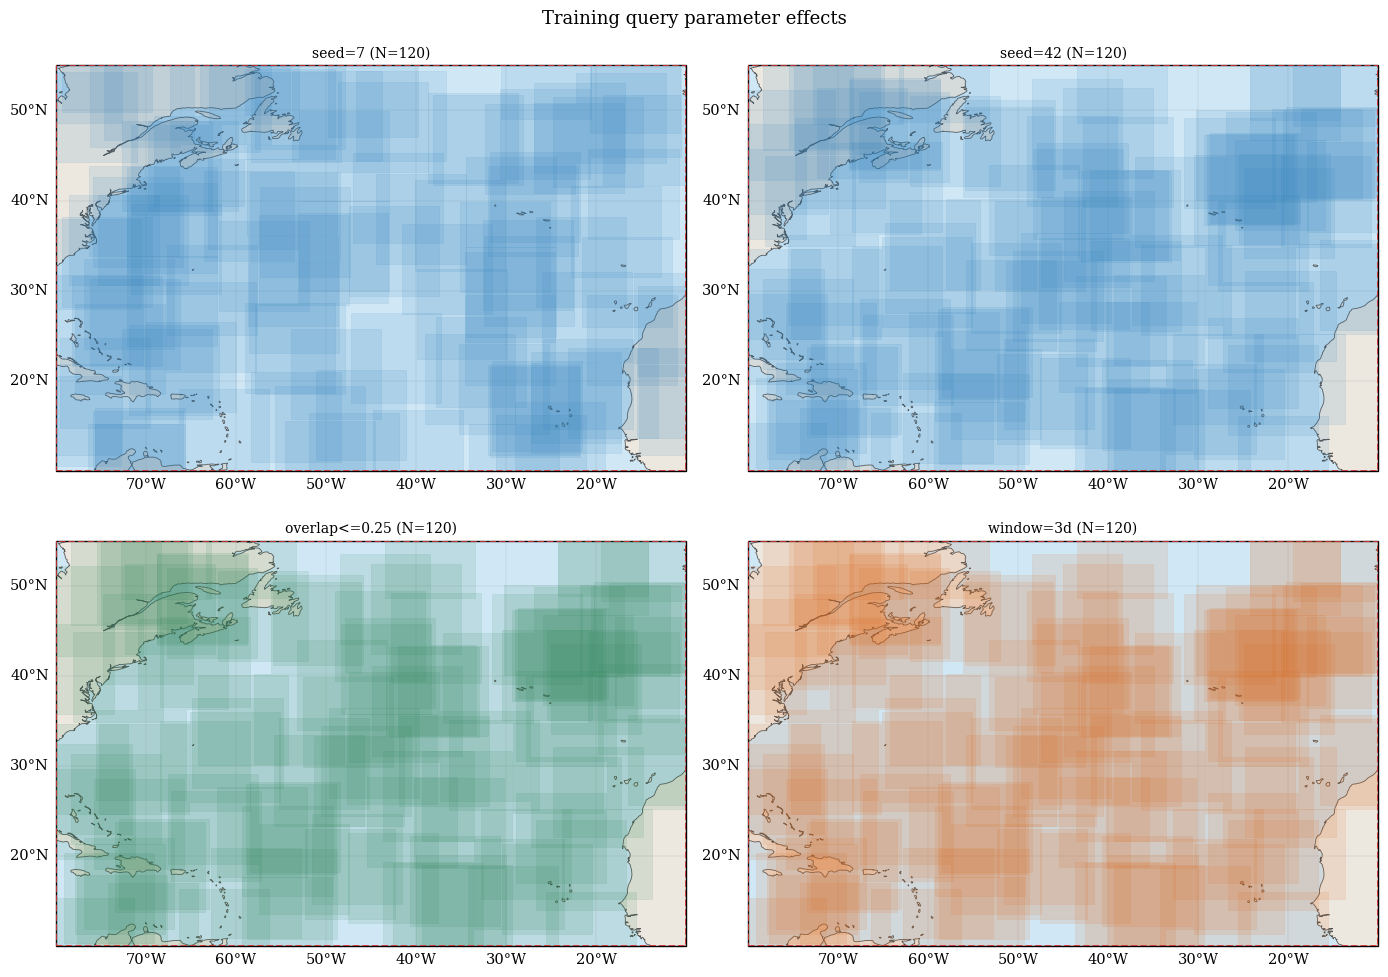

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flatten()

colors = {
    "seed=7": "#3182bd",
    "seed=42": "#3182bd",
    "overlap<=0.25": "#2f855a",
    "window=3d": "#dd6b20",
}

for ax, (name, queries) in zip(axes, training_results.items()):
    draw_query_map(
        ax=ax,
        queries=queries,
        title=f"{name} (N={len(queries)})",
        bbox=STUDY_BBOX,
        color=colors[name],
    )

fig.suptitle("Training query parameter effects", fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

In [6]:
print("Interpretation:")
print("- Changing seed changes placement pattern but not total requested count.")
print("- Lower max_spatial_overlap spreads samples out and reduces near-duplicates.")
print("- Larger time_window_days keeps spatial behavior but expands each query duration.")

for case_name in ["seed=42", "window=3d"]:
    q0 = training_results[case_name][0]
    print(f"{case_name}: first query time range = ({q0.time_start}, {q0.time_end})")

Interpretation:
- Changing seed changes placement pattern but not total requested count.
- Lower max_spatial_overlap spreads samples out and reduces near-duplicates.
- Larger time_window_days keeps spatial behavior but expands each query duration.
seed=42: first query time range = (2023-04-14, 2023-04-14)
window=3d: first query time range = (2023-04-14, 2023-04-16)


## 3. Eval Queries: Deterministic Grid Controls

We vary these parameters for `generate_eval_queries`:
- `spatial_overlap`: controls grid density in space
- `temporal_stride_days`: controls cadence in time
- `time_window_days`: controls time span of each query

In [7]:
eval_cases = {
    "overlap=0.0": dict(spatial_overlap=0.0, temporal_stride_days=7, time_window_days=1),
    "overlap=0.25": dict(spatial_overlap=0.25, temporal_stride_days=7, time_window_days=1),
    "overlap=0.5": dict(spatial_overlap=0.5, temporal_stride_days=7, time_window_days=1),
    "stride=3d": dict(spatial_overlap=0.0, temporal_stride_days=3, time_window_days=1),
    "window=3d": dict(spatial_overlap=0.0, temporal_stride_days=7, time_window_days=3),
}

eval_results = {}
for name, params in eval_cases.items():
    eval_results[name] = qg.generate_eval_queries(
        bbox=STUDY_BBOX,
        patch_size=PATCH_SIZE,
        date_range=EVAL_DATE_RANGE,
        max_land_fraction=0.5,
        verbose=False,
        **params,
    )

eval_summary = pd.DataFrame([
    summarize_queries(name, qs) for name, qs in eval_results.items()
]).sort_values("case")
eval_summary

,case,n_queries,n_unique_days,mean_patch_lon_deg,mean_patch_lat_deg
0,overlap=0.0,315,9,10.0,10.0
1,overlap=0.25,486,9,10.0,10.0
2,overlap=0.5,936,9,10.0,10.0
3,stride=3d,735,21,10.0,10.0
4,window=3d,315,9,10.0,10.0


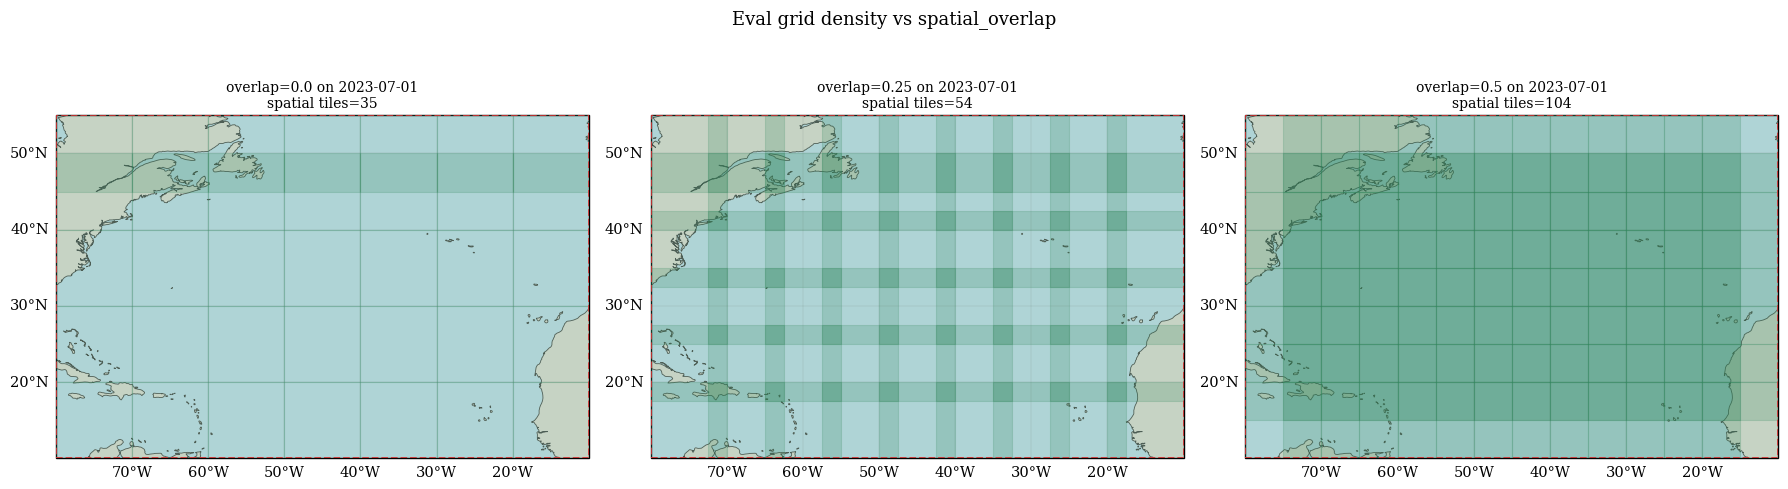

In [8]:
spatial_case_names = ["overlap=0.0", "overlap=0.25", "overlap=0.5"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={"projection": ccrs.PlateCarree()})

for ax, name in zip(axes, spatial_case_names):
    first_day = min(q.time_start for q in eval_results[name])
    same_day = [q for q in eval_results[name] if q.time_start == first_day]
    draw_query_map(
        ax=ax,
        queries=same_day,
        title=f"{name} on {first_day}\nspatial tiles={len(same_day)}",
        bbox=STUDY_BBOX,
        color="#2f855a",
        alpha=0.20,
        lw=0.8,
    )

fig.suptitle("Eval grid density vs spatial_overlap", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
def unique_starts(queries):
    return sorted(set(q.time_start for q in queries))

dates_stride7 = unique_starts(eval_results["overlap=0.0"])
dates_stride3 = unique_starts(eval_results["stride=3d"])
dates_window3 = unique_starts(eval_results["window=3d"])

print("Temporal cadence examples:")
print(f"- overlap=0.0 (stride=7d): {len(dates_stride7)} start dates -> {dates_stride7[:5]} ...")
print(f"- stride=3d:            {len(dates_stride3)} start dates -> {dates_stride3[:5]} ...")
print(f"- window=3d:            {len(dates_window3)} start dates; first query spans {eval_results['window=3d'][0].time_start} to {eval_results['window=3d'][0].time_end}")

print()
print("Interpretation:")
print("- Higher spatial_overlap creates denser grids and more total queries.")
print("- Lower temporal_stride_days creates more frequent temporal sampling.")
print("- Larger time_window_days extends each query time range while preserving deterministic grid placement.")

Temporal cadence examples:
- overlap=0.0 (stride=7d): 9 start dates -> ['2023-07-01', '2023-07-08', '2023-07-15', '2023-07-22', '2023-07-29'] ...
- stride=3d:            21 start dates -> ['2023-07-01', '2023-07-04', '2023-07-07', '2023-07-10', '2023-07-13'] ...
- window=3d:            9 start dates; first query spans 2023-07-01 to 2023-07-03

Interpretation:
- Higher spatial_overlap creates denser grids and more total queries.
- Lower temporal_stride_days creates more frequent temporal sampling.
- Larger time_window_days extends each query time range while preserving deterministic grid placement.


## Land Cover Filtering: Avoid Sampling Land Pixels

To bias sampling toward ocean-only patches, initialize `QueryGenerator` with a `land_mask_path` and use a strict `max_land_fraction`.

- `land_mask_path`: enables precomputed land/ocean filtering (cached to disk).
- `max_land_fraction`: reject candidates if land fraction exceeds this threshold.
- Typical values: `0.3` for mixed coastal/ocean training, `0.1` for mostly open-ocean training.

The demo below is optional because generating the mask the first time can take a few minutes.

Generating land mask from Natural Earth...


/home/nils/miniconda3/envs/testpy311/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


  Processing latitude 0/720
  Processing latitude 100/720
  Processing latitude 200/720
  Processing latitude 300/720
  Processing latitude 400/720
  Processing latitude 500/720
  Processing latitude 600/720
  Processing latitude 700/720


,case,n_queries,mean_land_fraction,max_land_fraction_observed,share_with_land_gt_0.2
1,max_land_fraction=0.1 (ocean-biased),120,0.008527,0.099346,0.000000
0,max_land_fraction=1.0 (no filter),120,0.121693,0.982153,0.183333


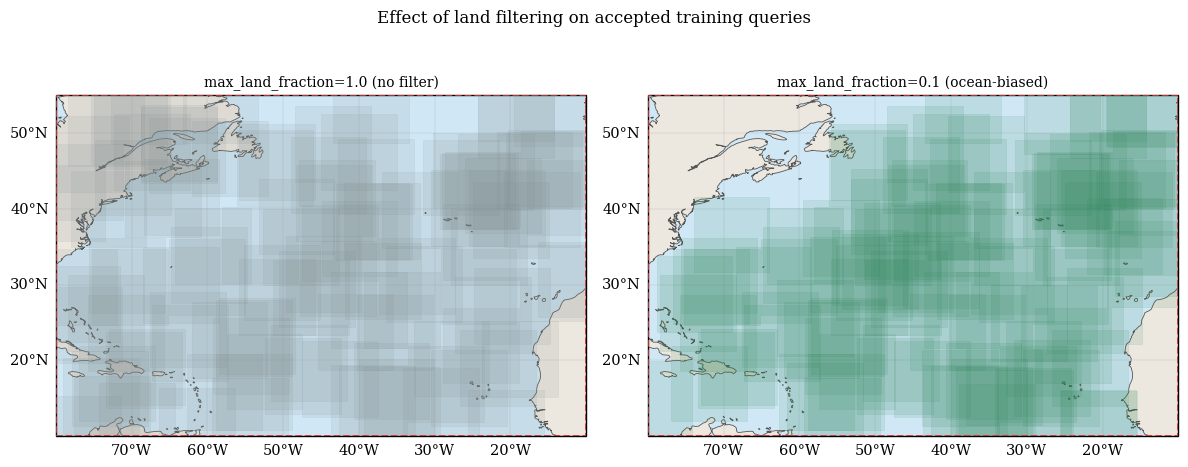

In [11]:
# Optional demo: set to True to run land-mask-aware sampling
RUN_LAND_MASK_DEMO = True
LAND_MASK_PATH = Path("./.cache/land_mask_025deg.npy")

if RUN_LAND_MASK_DEMO:
    qg_land = QueryGenerator(land_mask_path=LAND_MASK_PATH)
    
    # Compare permissive vs strict land filtering
    cases = {
        "max_land_fraction=1.0 (no filter)": 1.0,
        "max_land_fraction=0.1 (ocean-biased)": 0.1,
    }
    
    land_demo_results = {}
    for label, max_land in cases.items():
        qs = qg_land.generate_training_queries(
            n_queries=120,
            patch_size=PATCH_SIZE,
            date_range=TRAIN_DATE_RANGE,
            bbox_constraint=STUDY_BBOX,
            max_land_fraction=max_land,
            seed=42,
            verbose=False,
        )
        land_demo_results[label] = qs
    
    # Compute realized land fraction statistics from accepted queries
    rows = []
    for label, qs in land_demo_results.items():
        land_fracs = [qg_land.land_mask.get_land_fraction(q.bbox) for q in qs]
        rows.append(
            {
                "case": label,
                "n_queries": len(qs),
                "mean_land_fraction": float(np.mean(land_fracs)),
                "max_land_fraction_observed": float(np.max(land_fracs)),
                "share_with_land_gt_0.2": float(np.mean(np.array(land_fracs) > 0.2)),
            }
        )
    
    display(pd.DataFrame(rows).sort_values("case"))
    
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    colors = ["#7f8c8d", "#2f855a"]
    
    for ax, (label, qs), color in zip(axes, land_demo_results.items(), colors):
        draw_query_map(
            ax=ax,
            queries=qs,
            title=label,
            bbox=STUDY_BBOX,
            color=color,
            alpha=0.12,
            lw=0.5,
        )
    
    fig.suptitle("Effect of land filtering on accepted training queries", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Land-mask demo is disabled.")
    print("Set RUN_LAND_MASK_DEMO = True to generate a cached land mask and compare filtering behavior.")

## 4. Practical Rules of Thumb

- For training diversity, start with `max_spatial_overlap` in the 0.2 to 0.5 range.
- To avoid land-heavy patches, use `QueryGenerator(land_mask_path=...)` and set `max_land_fraction` to around `0.1` to `0.3`.
- For independent evaluation, use `spatial_overlap=0.0`.
- For dense sliding-window-style evaluation, increase `spatial_overlap` (for example 0.25 or 0.5).
- For smoother temporal metrics, reduce `temporal_stride_days` (at the cost of more queries).

See also: `ml_dataset.ipynb` for end-to-end dataset loading and batching examples.